# Week 6 — Ensembles & Advanced Stream Classifiers
## LU3.3 — Classification in Data Streams

### ❓ Big Question
**How can multiple incremental learners produce stronger stream models?**

**Estimated laboratory time:** ~1h15  
**Core protocol:** **PREDICT → EVALUATE → LEARN**

Week 5 asked what changes inside **one** incremental learner. Week 6 adds a second level of adaptation: several learners can receive different training histories, make different errors, combine their predictions, and sometimes replace weak members.

> **One learner evolves its own knowledge. An ensemble must also manage how knowledge is distributed across learners.**

## Learning map

| Stage | Question | Main object |
|---|---|---|
| Single learner | What can one model learn? | Hoeffding Tree |
| Online Bagging | How can one stream create different training histories? | Poisson resampling |
| Diversity | Do the members make different errors? | Disagreement |
| Voting | How are predictions combined? | Majority / weighted vote |
| Advanced ensembles | How can diversity and adaptation be engineered? | Leveraging Bagging, SRP, ARF |
| Cost | Is a larger ensemble worth it? | Time per event |
| Reusable framework | How do we turn this into an empirical study? | Benchmark pipeline |

### Main scientific principle

> **An ensemble is useful because competent members do not make exactly the same mistakes.**

## 0. Setup

The intended implementation uses **River**. The notebook records the installed River version because ensemble APIs are software implementations of algorithms described in papers.

```bash
pip install river
```

If River is unavailable, the notebook activates a **clearly labelled educational fallback** so the complete notebook can still execute. The fallback is **not** an implementation of Hoeffding Trees, SRP, or ARF and must never be reported as such.

For the classroom experiment, run with the real River package whenever possible.

In [1]:
import os
import math
import warnings
import importlib.util
import importlib.metadata as importlib_metadata
from itertools import combinations
from time import perf_counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

SEED = 42
RIVER_AVAILABLE = importlib.util.find_spec("river") is not None
SAVE_FIGURES = os.getenv("WEEK06_SAVE_FIGURES", "0") == "1"
FIG_DIR = os.getenv("WEEK06_FIG_DIR", "/mnt/data/week06_build/figures")

# Classroom defaults: substantial enough to show behaviour, small enough for a lab.
N_SAMPLES = 2400
WARMUP = 200
CHECKPOINT_EVERY = 50
ENSEMBLE_SIZE = 5
ENSEMBLE_SIZES = [1, 3, 5, 10, 20]
SIZE_EXPERIMENT_SAMPLES = 1600

if SAVE_FIGURES:
    os.makedirs(FIG_DIR, exist_ok=True)

try:
    river_version = importlib_metadata.version("river")
except importlib_metadata.PackageNotFoundError:
    river_version = "not installed — educational fallback active"

print(f"River available: {RIVER_AVAILABLE}")
print(f"River version: {river_version}")
print(f"Main stream size: {N_SAMPLES:,} events")
print(f"Shared warm-up: {WARMUP:,} events")


def finish_figure(filename=None):
    plt.tight_layout()
    if SAVE_FIGURES and filename:
        plt.savefig(os.path.join(FIG_DIR, filename), dpi=160, bbox_inches="tight")
    plt.show()
    plt.close()

River available: True
River version: 0.26.1
Main stream size: 2,400 events
Shared warm-up: 200 events


### Week 4 → Week 5 → Week 6

```text
Week 4                      Week 5                         Week 6
EVALUATION STATE            MODEL STATE                    POPULATION STATE
      ↓                           ↓                              ↓
metrics evolve              learner evolves               ensemble evolves
```

The chronological rule never changes:

```text
PREDICT  →  EVALUATE  →  LEARN
```

Keeping the evaluation protocol fixed is what makes the model comparison scientifically meaningful.

## 1. Build one controlled evolving stream (~6 min)

We use a six-dimensional synthetic stream with **three sequential regimes**. The decision rule changes between regimes so that the experiment exposes differences in adaptation behaviour.

We are **not** studying drift detection theory yet. The changing stream is simply an experimental instrument that lets us observe how ensembles behave when the predictive relationship does not remain identical forever.

> **Experimental question before algorithm:** the stream is designed to reveal a mechanism, not to make a favourite model win.

In [2]:
def make_evolving_stream(n_samples=2400, n_features=6, seed=42):
    """Controlled binary stream with three sequential predictive regimes."""
    if n_features < 6:
        raise ValueError("This demonstration expects at least 6 features.")

    rng = np.random.default_rng(seed)
    X = rng.normal(0.0, 1.0, size=(n_samples, n_features))
    noise = rng.normal(0.0, 0.35, size=n_samples)
    cut1 = n_samples // 3
    cut2 = 2 * n_samples // 3

    events = []
    for i in range(n_samples):
        x = X[i]
        if i < cut1:
            phase = 1
            score = 1.15*x[0] - 0.85*x[1] + 0.55*x[2] + 0.35*x[0]*x[1]
        elif i < cut2:
            phase = 2
            score = -0.55*x[0] + 1.10*x[2] - 0.90*x[3] + 0.55*x[4]
        else:
            phase = 3
            score = 0.90*x[1] - 1.00*x[2] + 0.70*x[4] + 0.80*x[5] - 0.35*x[0]*x[5]

        y = int(score + noise[i] > 0.0)
        events.append({
            "i": i,
            "phase": phase,
            "x": {f"x{j}": float(x[j]) for j in range(n_features)},
            "y": y,
        })
    return events


stream = make_evolving_stream(N_SAMPLES, seed=SEED)
stream_df = pd.DataFrame([
    {"i": e["i"], "phase": e["phase"], "y": e["y"], **e["x"]}
    for e in stream
])

display(stream_df.head())
display(pd.crosstab(stream_df["phase"], stream_df["y"], normalize="index").round(3))

,i,phase,y,x0,x1,x2,x3,x4,x5
0,0,1,1,0.304717,-1.039984,0.750451,0.940565,-1.951035,-1.302180
1,1,1,1,0.127840,-0.316243,-0.016801,-0.853044,0.879398,0.777792
2,2,1,0,0.066031,1.127241,0.467509,-0.859292,0.368751,-0.958883
3,3,1,1,0.878450,-0.049926,-0.184862,-0.680930,1.222541,-0.154529
4,4,1,1,-0.428328,-0.352134,0.532309,0.365444,0.412733,0.430821


y,0,1
phase,,
1,0.458,0.542
2,0.504,0.496
3,0.480,0.520


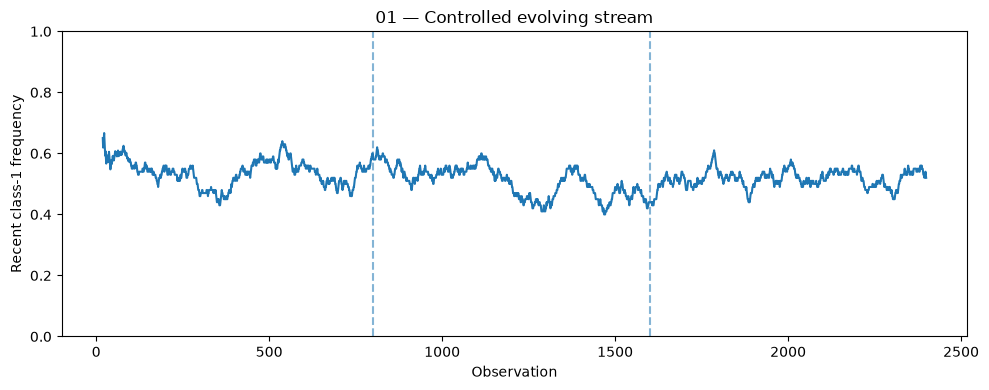

In [3]:
plt.figure(figsize=(10, 4))
rolling = stream_df["y"].rolling(100, min_periods=20).mean()
plt.plot(stream_df["i"], rolling)
for boundary in (N_SAMPLES // 3, 2 * N_SAMPLES // 3):
    plt.axvline(boundary, linestyle="--", alpha=0.55)
plt.ylim(0, 1)
plt.xlabel("Observation")
plt.ylabel("Recent class-1 frequency")
plt.title("01 — Controlled evolving stream")
finish_figure("01_evolving_stream.png")

<details>
<summary><strong>Exercise 1 — Why not use a random train/test split here?</strong></summary>

Because the stream has a temporal order and sequential regimes. Random shuffling would mix information from different moments, destroy the experimental chronology, and make adaptation impossible to interpret. The model must experience the stream in the order in which it is defined.

</details>

# Part I — From one learner to many
## 2. Online Bagging from first principles (~12 min)

Classical bagging draws bootstrap datasets. In an infinite stream we cannot repeatedly resample a completed dataset.

Oza's online approximation uses the fact that, for large bootstrap samples, the number of times an observation appears is approximately

$
K \sim \mathrm{Poisson}(1).
$

For one ensemble member:

$
P(K=k)=\frac{e^{-1}}{k!}.
$

So one observation may update a member **zero, one, two, or more times**.

> **Each member experiences a different training history even though there is only one global stream.**

,k updates,P(K=k)
0,0,0.3679
1,1,0.3679
2,2,0.1839
3,3,0.0613
4,4,0.0153
5,5,0.0031
6,6,0.0005


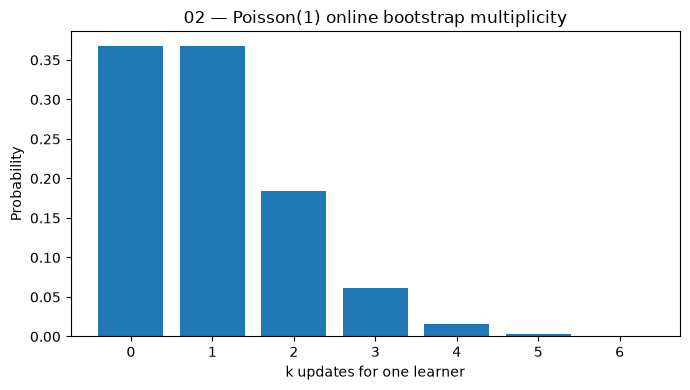

In [4]:
# Visualize the Poisson(1) mechanism before building the ensemble.
ks = np.arange(0, 7)
poisson_p = np.exp(-1.0) / np.array([math.factorial(int(k)) for k in ks])
poisson_df = pd.DataFrame({"k updates": ks, "P(K=k)": poisson_p})
display(poisson_df.round(4))

plt.figure(figsize=(7, 4))
plt.bar(ks, poisson_p)
plt.xlabel("k updates for one learner")
plt.ylabel("Probability")
plt.title("02 — Poisson(1) online bootstrap multiplicity")
finish_figure("02_poisson1.png")

### Learner backend

With River installed, the base learner below is a real `HoeffdingTreeClassifier`. Without River, a small `SGDClassifier` adapter is used **only to keep the notebook executable**.

This distinction is intentionally visible in the output.

In [5]:
if RIVER_AVAILABLE:
    from river import ensemble, forest, tree


class FastLinearFallback:
    """Tiny educational online linear learner used only when River is unavailable."""
    def __init__(self, n_features=6, seed=42, learning_rate=0.035, l2=1e-4):
        self.n_features = n_features
        self.seed = seed
        self.learning_rate = learning_rate
        self.l2 = l2
        self.weights = np.zeros(n_features, dtype=float)
        self.bias = 0.0

    def _vec(self, x):
        return np.array([x.get(f"x{i}", 0.0) for i in range(self.n_features)], dtype=float)

    def predict_one(self, x):
        z = float(np.dot(self.weights, self._vec(x)) + self.bias)
        return int(z >= 0.0)

    def learn_one(self, x, y):
        v = self._vec(x)
        z = float(np.dot(self.weights, v) + self.bias)
        z = float(np.clip(z, -30.0, 30.0))
        p = 1.0 / (1.0 + math.exp(-z))
        error = float(y) - p
        self.weights = (1.0 - self.learning_rate * self.l2) * self.weights + self.learning_rate * error * v
        self.bias += self.learning_rate * error
        return self


def make_base_tree(seed=42):
    if RIVER_AVAILABLE:
        return tree.HoeffdingTreeClassifier(
            grace_period=30,
            delta=1e-3,
            tau=0.10,
            leaf_prediction="mc",
        )
    return FastLinearFallback(n_features=6, seed=seed)


def safe_prediction(model, x, default=0):
    pred = model.predict_one(x)
    return default if pred is None else int(pred)


print("Base learner:", type(make_base_tree()).__name__)
if not RIVER_AVAILABLE:
    print("NOTE: fallback mode is for execution only; do not interpret it as a Hoeffding Tree result.")

Base learner: HoeffdingTreeClassifier


In [6]:
class ManualOnlineBagging:
    """Minimal Online Bagging implementation for teaching Poisson resampling."""
    def __init__(self, base_factory, n_models=5, lam=1.0, seed=42):
        self.n_models = n_models
        self.lam = float(lam)
        self.rng = np.random.default_rng(seed)
        self.models = [base_factory(seed + i) for i in range(n_models)]
        self.correct = np.zeros(n_models, dtype=float)
        self.scored = np.zeros(n_models, dtype=float)

    def predict_members(self, x):
        return np.array([safe_prediction(model, x) for model in self.models], dtype=int)

    def weights(self):
        # Laplace-smoothed online accuracy: avoids zero weights at the beginning.
        return (self.correct + 1.0) / (self.scored + 2.0)

    def predict_one(self, x):
        preds = self.predict_members(x)
        return int(np.mean(preds) >= 0.5)

    def predict_weighted_one(self, x):
        preds = self.predict_members(x)
        w = self.weights()
        score_1 = float(np.sum(w[preds == 1]))
        score_0 = float(np.sum(w[preds == 0]))
        return int(score_1 >= score_0)

    def update_member_scores(self, member_predictions, y):
        self.correct += (member_predictions == y).astype(float)
        self.scored += 1.0

    def learn_one(self, x, y):
        k_values = self.rng.poisson(self.lam, size=self.n_models)
        for k, model in zip(k_values, self.models):
            for _ in range(int(k)):
                model.learn_one(x, y)
        return k_values

In [7]:
manual = ManualOnlineBagging(make_base_tree, n_models=5, lam=1.0, seed=SEED)
poisson_trace = []
member_rows = []
vote_rows = []
manual_warmup = 80

for e in stream[:700]:
    x, y = e["x"], e["y"]
    member_preds = manual.predict_members(x)
    majority_pred = int(np.mean(member_preds) >= 0.5)
    weighted_pred = manual.predict_weighted_one(x)

    if e["i"] >= manual_warmup:
        member_rows.append({"i": e["i"], **{f"M{j+1}": int(p) for j, p in enumerate(member_preds)}})
        vote_rows.append({
            "i": e["i"], "y": y,
            "majority": majority_pred,
            "weighted": weighted_pred,
        })
        manual.update_member_scores(member_preds, y)

    k_values = manual.learn_one(x, y)
    if len(poisson_trace) < 12:
        poisson_trace.append({"i": e["i"], **{f"K{j+1}": int(k) for j, k in enumerate(k_values)}})

poisson_trace_df = pd.DataFrame(poisson_trace)
member_predictions_df = pd.DataFrame(member_rows)
vote_df = pd.DataFrame(vote_rows)

display(poisson_trace_df)
print("Final smoothed member weights:", np.round(manual.weights(), 3))

,i,K1,K2,K3,K4,K5
0,0,1,2,3,1,3
1,1,0,1,3,3,1
2,2,0,3,1,0,0
3,3,1,1,2,2,0
4,4,1,0,0,3,1
5,5,0,0,1,2,1
6,6,0,0,1,1,0
7,7,0,0,0,2,1
8,8,1,0,0,1,0
9,9,1,1,1,1,0


Final smoothed member weights: [0.73  0.712 0.732 0.76  0.765]


### What should you notice?

The rows in the table are the **same observations**, but the columns `K1 ... K5` are different Poisson draws. This is the mechanism that generates different update histories.

<details>
<summary><strong>Exercise 2 — Predict before looking</strong></summary>

For `Poisson(1)`, approximately 36.8% of the draws are zero. Therefore, for a given event, it is completely normal for some ensemble members not to update at all.

This is not a bug. It is the online bootstrap mechanism.

</details>

# Part II — Diversity & Voting
## 3. Do the members actually disagree? (~8 min)

A simple pairwise disagreement measure is

$
D_{ij}=\frac{1}{N}\sum_{t=1}^{N}\mathbb{I}[h_i(x_t)\neq h_j(x_t)].
$

- `0` means the two members always agree;
- larger values mean their predictions differ more often.

But disagreement alone is **not** a quality metric.

> **Two bad classifiers can be very diverse. Diversity matters only together with competence.**

,M1,M2,M3,M4,M5
M1,1.000,0.227,0.144,0.253,0.210
M2,0.227,1.000,0.323,0.390,0.324
M3,0.144,0.323,1.000,0.129,0.085
M4,0.253,0.390,0.129,1.000,0.066
M5,0.210,0.324,0.085,0.066,1.000


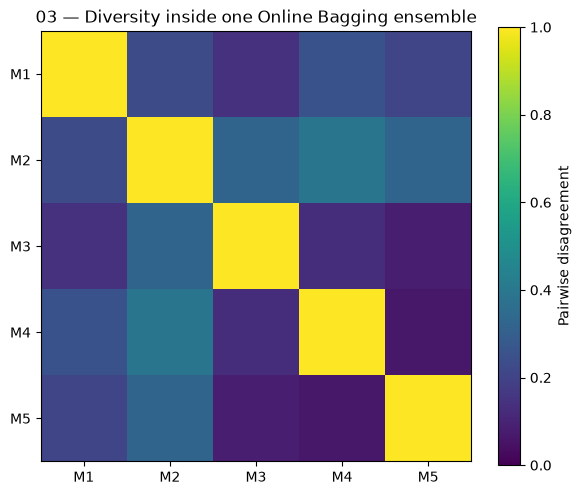

In [8]:
def pairwise_disagreement(predictions_df):
    model_cols = [c for c in predictions_df.columns if c.startswith("M")]
    mat = np.eye(len(model_cols), dtype=float)
    for i, j in combinations(range(len(model_cols)), 2):
        a = predictions_df[model_cols[i]].to_numpy()
        b = predictions_df[model_cols[j]].to_numpy()
        d = float(np.mean(a != b))
        mat[i, j] = d
        mat[j, i] = d
    return pd.DataFrame(mat, index=model_cols, columns=model_cols)


disagreement_df = pairwise_disagreement(member_predictions_df)
display(disagreement_df.round(3))

plt.figure(figsize=(6, 5))
plt.imshow(disagreement_df.to_numpy(), vmin=0, vmax=max(0.01, disagreement_df.to_numpy().max()))
plt.colorbar(label="Pairwise disagreement")
plt.xticks(range(len(disagreement_df.columns)), disagreement_df.columns)
plt.yticks(range(len(disagreement_df.index)), disagreement_df.index)
plt.title("03 — Diversity inside one Online Bagging ensemble")
finish_figure("03_pairwise_disagreement.png")

In [9]:
def binary_accuracy(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    return float(np.mean(y_true == y_pred))

vote_comparison = pd.DataFrame({
    "Voting strategy": ["Majority vote", "Performance-weighted vote"],
    "Accuracy": [
        binary_accuracy(vote_df["y"], vote_df["majority"]),
        binary_accuracy(vote_df["y"], vote_df["weighted"]),
    ],
})
display(vote_comparison.round(4))

,Voting strategy,Accuracy
0,Majority vote,0.75
1,Performance-weighted vote,0.75


### Discussion

A weighted vote adds a second learning problem:

```text
Level 1 — each member learns the stream
Level 2 — the ensemble learns whom to trust
```

This is why an adaptive ensemble is more than a collection of independent classifiers.

> **Question:** should a learner that was excellent early in the stream keep the same influence forever?

# Part III — Real streaming ensembles
## 4. One common experiment, five model families (~18 min)

Now we stop implementing the algorithms manually and use the real River implementations when available.

We compare:

1. **Single Hoeffding Tree** — one structurally evolving learner;
2. **Online Bagging** — Poisson(1) resampling;
3. **Leveraging Bagging** — stronger resampling plus adaptive member monitoring;
4. **Streaming Random Patches (SRP)** — instance diversity + feature-subspace diversity;
5. **Adaptive Random Forest (ARF)** — randomized stream trees with adaptive mechanisms.

Every model receives the **same warm-up** and the **same future observations**.

In [10]:
class OnlineBinaryMetrics:
    def __init__(self):
        self.cm = np.zeros((2, 2), dtype=int)

    def update(self, y, y_pred):
        self.cm[int(y), int(y_pred)] += 1

    @property
    def n(self):
        return int(self.cm.sum())

    def accuracy(self):
        return float(np.trace(self.cm) / self.n) if self.n else 0.0

    def macro_f1(self):
        f1s = []
        for c in (0, 1):
            tp = self.cm[c, c]
            fp = self.cm[1-c, c]
            fn = self.cm[c, 1-c]
            precision = tp / (tp + fp) if (tp + fp) else 0.0
            recall = tp / (tp + fn) if (tp + fn) else 0.0
            f1 = 2 * precision * recall / (precision + recall) if (precision + recall) else 0.0
            f1s.append(f1)
        return float(np.mean(f1s))


class FallbackEnsemble:
    """Educational fallback ensemble. Not a substitute for River algorithms."""
    def __init__(self, n_models=5, lam=1.0, seed=42, subspace_fraction=1.0, weighted=False):
        if n_models < 2:
            raise ValueError("FallbackEnsemble requires at least 2 members, matching River ensemble constraints.")
        self.n_models = n_models
        self.lam = lam
        self.seed = seed
        self.rng = np.random.default_rng(seed)
        self.weighted = weighted
        self.feature_names = [f"x{i}" for i in range(6)]
        self.models = [FastLinearFallback(6, seed + i) for i in range(n_models)]
        self.correct = np.zeros(n_models, dtype=float)
        self.scored = np.zeros(n_models, dtype=float)
        m = max(2, int(math.ceil(len(self.feature_names) * subspace_fraction)))
        self.subspaces = [
            set(self.rng.choice(self.feature_names, size=m, replace=False).tolist())
            if subspace_fraction < 1.0 else set(self.feature_names)
            for _ in range(n_models)
        ]

    def _subx(self, x, j):
        return {k: v for k, v in x.items() if k in self.subspaces[j]}

    def predict_one(self, x):
        preds = np.array([safe_prediction(m, self._subx(x, j)) for j, m in enumerate(self.models)])
        if not self.weighted:
            return int(np.mean(preds) >= 0.5)
        w = (self.correct + 1.0) / (self.scored + 2.0)
        return int(np.sum(w[preds == 1]) >= np.sum(w[preds == 0]))

    def learn_one(self, x, y):
        preds = np.array([safe_prediction(m, self._subx(x, j)) for j, m in enumerate(self.models)])
        self.correct += (preds == y).astype(float)
        self.scored += 1.0
        for j, model in enumerate(self.models):
            k = int(self.rng.poisson(self.lam))
            for _ in range(k):
                model.learn_one(self._subx(x, j), y)
        return self


def make_model_factories(n_models=5, seed=42):
    """Fresh model factory functions for fair repeated experiments."""
    if RIVER_AVAILABLE:
        return {
            "Hoeffding Tree": lambda: make_base_tree(seed),
            "Online Bagging": lambda: ensemble.BaggingClassifier(
                model=make_base_tree(seed), n_models=n_models, seed=seed
            ),
            "Leveraging Bagging": lambda: ensemble.LeveragingBaggingClassifier(
                model=make_base_tree(seed), n_models=n_models, w=6, seed=seed
            ),
            "Streaming Random Patches": lambda: ensemble.SRPClassifier(
                model=make_base_tree(seed), n_models=n_models,
                subspace_size=0.6, training_method="patches", lam=6, seed=seed
            ),
            "Adaptive Random Forest": lambda: forest.ARFClassifier(
                n_models=n_models, max_features="sqrt", lambda_value=6,
                leaf_prediction="mc", grace_period=30, delta=1e-3,
                tau=0.10, seed=seed
            ),
        }

    return {
        "Hoeffding Tree [fallback]": lambda: FastLinearFallback(6, seed),
        "Online Bagging [fallback]": lambda: FallbackEnsemble(n_models, 1.0, seed, 1.0, False),
        "Leveraging Bagging [fallback]": lambda: FallbackEnsemble(n_models, 6.0, seed, 1.0, True),
        "Streaming Random Patches [fallback]": lambda: FallbackEnsemble(n_models, 6.0, seed, 0.6, True),
        "Adaptive Random Forest [fallback]": lambda: FallbackEnsemble(n_models, 6.0, seed, 0.6, True),
    }

In [11]:
def model_complexity(model):
    """Return an intentionally simple, interpretable complexity snapshot."""
    if hasattr(model, "n_nodes"):
        try:
            return int(model.n_nodes), f"{int(model.n_nodes)} nodes"
        except Exception:
            pass
    if hasattr(model, "models"):
        try:
            n = len(model.models)
            return int(n), f"{n} members"
        except Exception:
            pass
    if hasattr(model, "n_models"):
        try:
            n = int(model.n_models)
            return n, f"{n} members"
        except Exception:
            pass
    return np.nan, "not exposed"


def run_stream_benchmark(stream, model_factories, warmup=200, checkpoint_every=50):
    """Fair prequential benchmark: same stream, same warm-up, fresh model per strategy."""
    models = {name: factory() for name, factory in model_factories.items()}
    metrics_state = {name: OnlineBinaryMetrics() for name in models}
    timing = {name: {"predict": 0.0, "update": 0.0, "n": 0} for name in models}
    history = []

    # Shared chronological warm-up. No evaluation metric is updated here.
    for e in stream[:warmup]:
        for model in models.values():
            model.learn_one(e["x"], e["y"])

    evaluated = stream[warmup:]
    for j, e in enumerate(evaluated, start=1):
        for name, model in models.items():
            t0 = perf_counter()
            y_pred = safe_prediction(model, e["x"])
            timing[name]["predict"] += perf_counter() - t0

            metrics_state[name].update(e["y"], y_pred)

            t0 = perf_counter()
            model.learn_one(e["x"], e["y"])
            timing[name]["update"] += perf_counter() - t0
            timing[name]["n"] += 1

            if j % checkpoint_every == 0 or j == len(evaluated):
                history.append({
                    "event": j,
                    "stream_i": e["i"],
                    "phase": e["phase"],
                    "model": name,
                    "accuracy": metrics_state[name].accuracy(),
                    "macro_f1": metrics_state[name].macro_f1(),
                })

    rows = []
    for name, model in models.items():
        n = max(1, timing[name]["n"])
        pred_ms = 1000 * timing[name]["predict"] / n
        upd_ms = 1000 * timing[name]["update"] / n
        total_seconds = timing[name]["predict"] + timing[name]["update"]
        complexity_value, complexity_state = model_complexity(model)
        rows.append({
            "Model": name,
            "Accuracy": metrics_state[name].accuracy(),
            "Macro-F1": metrics_state[name].macro_f1(),
            "Predict ms/event": pred_ms,
            "Update ms/event": upd_ms,
            "Throughput events/s": n / total_seconds if total_seconds else np.inf,
            "Complexity": complexity_value,
            "Complexity state": complexity_state,
        })

    return pd.DataFrame(history), pd.DataFrame(rows), models


model_factories = make_model_factories(ENSEMBLE_SIZE, SEED)
history_df, benchmark_df, trained_models = run_stream_benchmark(
    stream, model_factories, warmup=WARMUP, checkpoint_every=CHECKPOINT_EVERY
)

display(benchmark_df.round(4))

,Model,Accuracy,Macro-F1,Predict ms/event,Update ms/event,Throughput events/s,Complexity,Complexity state
0,Hoeffding Tree,0.5700,0.5652,0.0175,0.0505,14714.3702,17,17 nodes
1,Online Bagging,0.6027,0.6017,0.0924,0.2259,3141.7977,5,5 members
2,Leveraging Bagging,0.7773,0.7767,0.0919,1.2660,736.4037,5,5 members
3,Streaming Random Patches,0.7700,0.7698,0.0990,1.1193,820.8170,5,5 members
4,Adaptive Random Forest,0.7586,0.7575,0.1105,0.6092,1389.5751,5,5 members


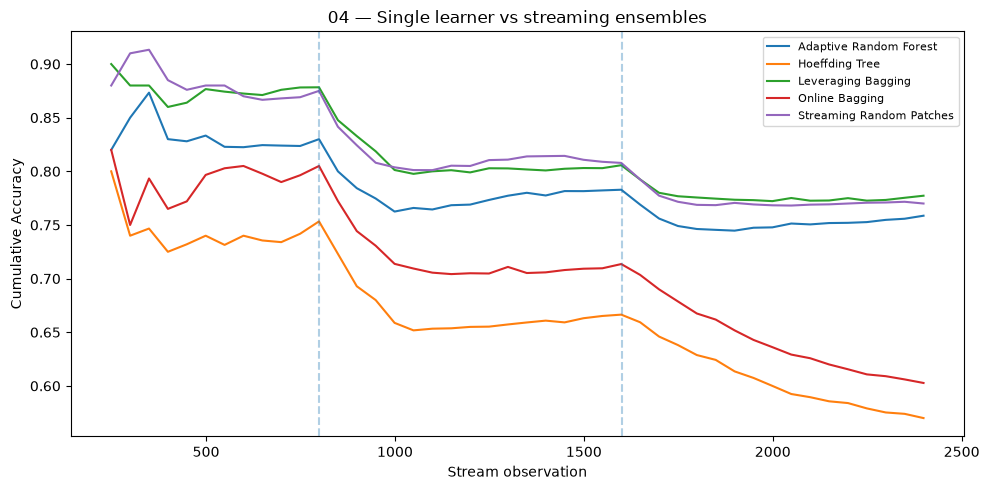

In [12]:
plt.figure(figsize=(10, 5))
for name, part in history_df.groupby("model"):
    plt.plot(part["stream_i"], part["accuracy"], label=name)
for boundary in (N_SAMPLES // 3, 2 * N_SAMPLES // 3):
    plt.axvline(boundary, linestyle="--", alpha=0.35)
plt.xlabel("Stream observation")
plt.ylabel("Cumulative Accuracy")
plt.title("04 — Single learner vs streaming ensembles")
plt.legend(fontsize=8)
finish_figure("04_single_vs_ensembles_accuracy.png")

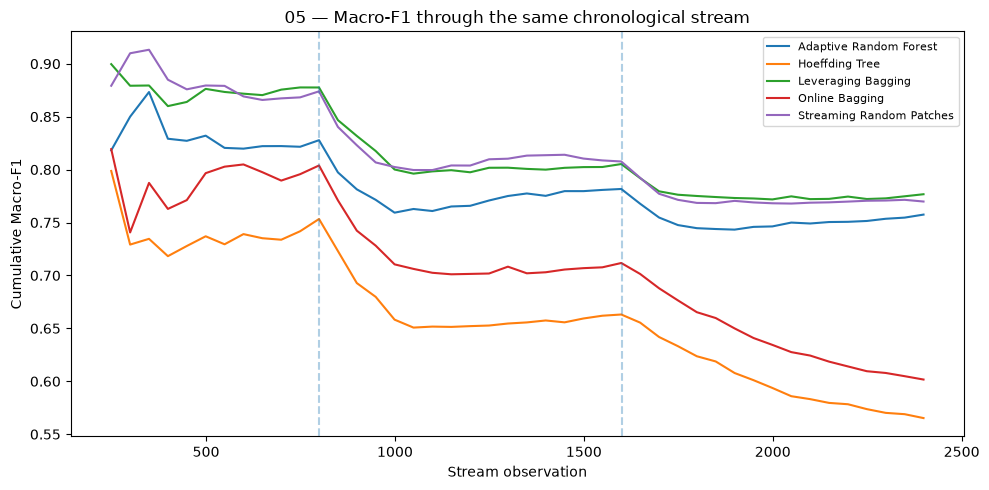

In [13]:
plt.figure(figsize=(10, 5))
for name, part in history_df.groupby("model"):
    plt.plot(part["stream_i"], part["macro_f1"], label=name)
for boundary in (N_SAMPLES // 3, 2 * N_SAMPLES // 3):
    plt.axvline(boundary, linestyle="--", alpha=0.35)
plt.xlabel("Stream observation")
plt.ylabel("Cumulative Macro-F1")
plt.title("05 — Macro-F1 through the same chronological stream")
plt.legend(fontsize=8)
finish_figure("05_single_vs_ensembles_f1.png")

### Interpretation discipline

Do **not** read the table as a leaderboard.

Ask instead:

- How much predictive change did the ensemble buy?
- How much more expensive was prediction?
- How much more expensive was updating?
- Did all ensemble strategies behave similarly?
- What mechanism distinguishes Online Bagging, SRP, and ARF?

> **A benchmark is useful when it explains a trade-off, not when it merely declares a winner.**

<details>
<summary><strong>Exercise 3 — Mechanism check</strong></summary>

Match each mechanism to the model family:

- **Poisson(1) resampling** → Online Bagging
- **higher resampling intensity + adaptive member monitoring** → Leveraging Bagging
- **resampling + random feature subspaces** → Streaming Random Patches
- **randomized stream trees + feature randomization + adaptive tree-level mechanisms** → Adaptive Random Forest

</details>

# Part IV — Does a larger ensemble justify its cost?
## 5. Ensemble size as an experimental variable (~10 min)

An ensemble introduces a parameter that a single learner does not have:

$
M = \text{number of learners}.
$

A rough intuition is

$
T_{predict} \propto M,
\qquad
T_{update} \propto M,
$

although exact runtime depends on the algorithm and implementation.

### Important implementation detail

River's `BaggingClassifier` requires **at least two ensemble members**. Therefore, the point `M = 1` in this experiment is deliberately implemented as a **single Hoeffding Tree using the same base-learner configuration**. For `M >= 2`, we use Online Bagging.

This gives us a scientifically useful continuum:

```text
M = 1  → single Hoeffding Tree baseline
M >= 2 → Online Bagging with M members
```

> **Does moving from one learner to a larger ensemble buy enough predictive improvement to justify its processing cost?**


In [14]:
def ensemble_size_experiment(stream, sizes=(1, 3, 5, 10, 20), warmup=200, seed=42):
    """Compare one base learner against Online Bagging ensembles of increasing size.

    River requires BaggingClassifier(n_models >= 2). To preserve M=1 as a
    pedagogically useful baseline, size=1 is evaluated with the same single
    Hoeffding Tree used as the bagging base learner.
    """
    rows = []
    for size in sizes:
        factories = make_model_factories(n_models=max(2, size), seed=seed)

        if size == 1:
            model_key = next(k for k in factories if k.startswith("Hoeffding Tree"))
            configuration = "Single Hoeffding Tree baseline"
        else:
            model_key = next(k for k in factories if k.startswith("Online Bagging"))
            configuration = f"Online Bagging ({size} members)"

        _, summary, _ = run_stream_benchmark(
            stream, {model_key: factories[model_key]}, warmup=warmup,
            checkpoint_every=max(50, len(stream) // 8)
        )
        row = summary.iloc[0].to_dict()
        row["n_models"] = size
        row["Configuration"] = configuration
        rows.append(row)

    return pd.DataFrame(rows).sort_values("n_models").reset_index(drop=True)


size_stream = stream[:SIZE_EXPERIMENT_SAMPLES]
size_df = ensemble_size_experiment(
    size_stream, sizes=ENSEMBLE_SIZES, warmup=min(WARMUP, 150), seed=SEED
)
display(size_df[[
    "n_models", "Configuration", "Accuracy", "Macro-F1",
    "Predict ms/event", "Update ms/event"
]].round(4))


,n_models,Configuration,Accuracy,Macro-F1,Predict ms/event,Update ms/event
0,1,Single Hoeffding Tree baseline,0.6690,0.6658,0.0134,0.0436
1,3,Online Bagging (3 members),0.7007,0.6930,0.0582,0.1589
2,5,Online Bagging (5 members),0.7138,0.7120,0.0736,0.2323
3,10,Online Bagging (10 members),0.6897,0.6878,0.1395,0.4675
4,20,Online Bagging (20 members),0.7028,0.7007,0.2903,1.0531


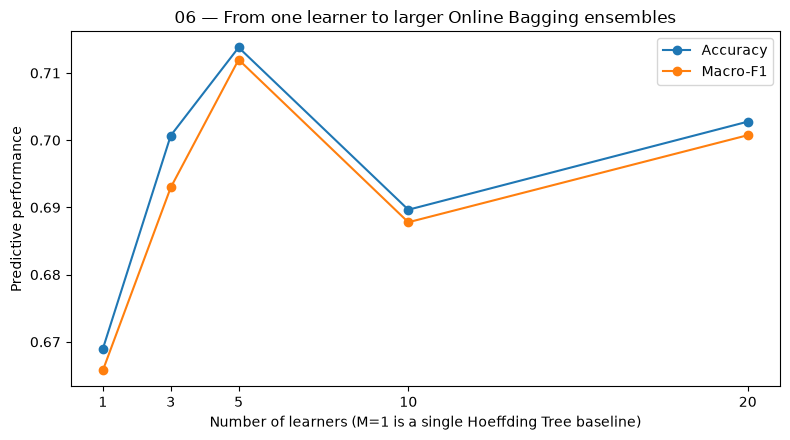

In [15]:
plt.figure(figsize=(8, 4.5))
plt.plot(size_df["n_models"], size_df["Accuracy"], marker="o", label="Accuracy")
plt.plot(size_df["n_models"], size_df["Macro-F1"], marker="o", label="Macro-F1")
plt.xticks(size_df["n_models"])
plt.xlabel("Number of learners (M=1 is a single Hoeffding Tree baseline)")
plt.ylabel("Predictive performance")
plt.title("06 — From one learner to larger Online Bagging ensembles")
plt.legend()
finish_figure("06_ensemble_size_performance.png")


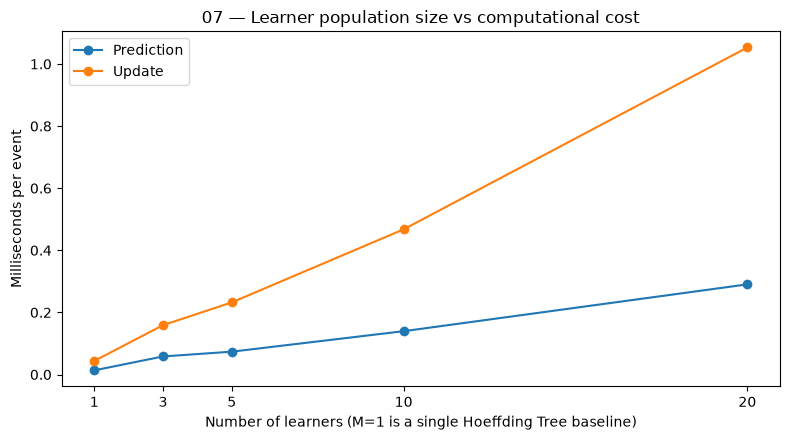

In [16]:
plt.figure(figsize=(8, 4.5))
plt.plot(size_df["n_models"], size_df["Predict ms/event"], marker="o", label="Prediction")
plt.plot(size_df["n_models"], size_df["Update ms/event"], marker="o", label="Update")
plt.xticks(size_df["n_models"])
plt.xlabel("Number of learners (M=1 is a single Hoeffding Tree baseline)")
plt.ylabel("Milliseconds per event")
plt.title("07 — Learner population size vs computational cost")
plt.legend()
finish_figure("07_ensemble_size_cost.png")


### The point of this experiment is not monotonic accuracy

Do not expect accuracy to increase perfectly every time `M` increases.

Remember that `M = 1` is the **single Hoeffding Tree baseline**, while `M >= 2` represents Online Bagging ensembles. The scientific question is whether the **marginal predictive benefit** of moving to larger populations remains meaningful relative to the additional computational cost.

<details>
<summary><strong>Exercise 4 — Write one evidence-based sentence</strong></summary>

Complete this sentence using your actual output:

> Moving from the single Hoeffding Tree (`M=1`) to Online Bagging with ___ members changed Macro-F1 from ___ to ___ while update time changed from ___ to ___ ms/event; therefore, under this stream and implementation, ...

Notice the wording: **under this stream and implementation**. Avoid universal conclusions from one run.

</details>


# Part V — Inspect the ensemble, not only the score
## 6. Population state and adaptive state (~8 min)

Week 5 inspected model state such as tree nodes and fuzzy rules. An ensemble introduces another state level:

```text
member state        → what each learner knows
population state    → which learners exist
combination state   → how their predictions are weighted
adaptive state      → warnings / replacements / resets when exposed
```

For ARF, River exposes warning and drift counters. We inspect those counters **without teaching the detector mathematics yet**.

In [17]:
def extract_adaptation_state(name, model):
    row = {"Model": name}
    complexity_value, complexity_state = model_complexity(model)
    row["Complexity"] = complexity_value
    row["Complexity state"] = complexity_state

    if hasattr(model, "n_warnings_detected"):
        try:
            row["Warnings detected"] = int(model.n_warnings_detected())
        except Exception:
            row["Warnings detected"] = np.nan
    else:
        row["Warnings detected"] = np.nan

    if hasattr(model, "n_drifts_detected"):
        try:
            row["Drifts detected"] = int(model.n_drifts_detected())
        except Exception:
            row["Drifts detected"] = np.nan
    else:
        row["Drifts detected"] = np.nan
    return row


adaptation_df = pd.DataFrame([
    extract_adaptation_state(name, model)
    for name, model in trained_models.items()
])
display(adaptation_df)

,Model,Complexity,Complexity state,Warnings detected,Drifts detected
0,Hoeffding Tree,17,17 nodes,NaN,NaN
1,Online Bagging,5,5 members,NaN,NaN
2,Leveraging Bagging,5,5 members,NaN,NaN
3,Streaming Random Patches,5,5 members,NaN,NaN
4,Adaptive Random Forest,5,5 members,9.0,7.0


### A zero counter is still an observation

If ARF reports zero warnings or zero detected changes in your run, **do not manufacture a story**. It means the detector settings and this stream did not produce those events during this experiment.

The detector mechanism will be studied explicitly later in the course.

> **Scientific honesty includes reporting when an expected mechanism was not activated.**

In [18]:
# Optional experiment: weighted voting inside ARF.
# The River API exposes disable_weighted_vote, which makes voting strategy testable.
if RIVER_AVAILABLE:
    weighted_factories = {
        "ARF weighted vote": lambda: forest.ARFClassifier(
            n_models=ENSEMBLE_SIZE, max_features="sqrt", lambda_value=6,
            disable_weighted_vote=False, leaf_prediction="mc",
            grace_period=30, delta=1e-3, tau=0.10, seed=SEED
        ),
        "ARF equal vote": lambda: forest.ARFClassifier(
            n_models=ENSEMBLE_SIZE, max_features="sqrt", lambda_value=6,
            disable_weighted_vote=True, leaf_prediction="mc",
            grace_period=30, delta=1e-3, tau=0.10, seed=SEED
        ),
    }
    _, voting_df, _ = run_stream_benchmark(
        stream[:1800], weighted_factories, warmup=150, checkpoint_every=100
    )
    display(voting_df[["Model", "Accuracy", "Macro-F1", "Predict ms/event", "Update ms/event"]].round(4))
else:
    print("Optional ARF voting experiment requires River; skipped in fallback mode.")

,Model,Accuracy,Macro-F1,Predict ms/event,Update ms/event
0,ARF weighted vote,0.7485,0.7467,0.1188,0.6483
1,ARF equal vote,0.7509,0.7493,0.1102,0.6328


<details>
<summary><strong>Exercise 5 — Why is this a better experiment than simply comparing ARF with another algorithm?</strong></summary>

Because both rows use the same ARF family and differ primarily in one mechanism: the vote weighting strategy. This isolates the question much more cleanly than changing several algorithmic components at once.

</details>

# Part VI — A reusable experiment framework
## 7. The artifact that continues into Week 7 (~10 min)

The most important output of this laboratory is not one particular accuracy value. It is the **experimental infrastructure**.

The function already used above accepts:

```python
run_stream_benchmark(
    stream=...,
    model_factories=...,
    warmup=...,
    checkpoint_every=...,
)
```

That means a later investigation can change the dataset, learner family, parameters, or research question **without rewriting the chronological evaluation protocol**.

In [19]:
# Example starter configuration for a new empirical investigation.
experiment_config = {
    "question": "How does ensemble size affect predictive performance and computational cost?",
    "stream": "controlled evolving six-feature stream",
    "warmup": WARMUP,
    "checkpoint_every": CHECKPOINT_EVERY,
    "random_seed": SEED,
    "primary_metrics": ["Accuracy", "Macro-F1"],
    "computational_metrics": ["Predict ms/event", "Update ms/event", "Throughput events/s"],
}

model_registry = make_model_factories(n_models=ENSEMBLE_SIZE, seed=SEED)

print("EXPERIMENT QUESTION")
print(experiment_config["question"])
print("\nAVAILABLE MODEL FAMILIES")
for name in model_registry:
    print(" -", name)

EXPERIMENT QUESTION
How does ensemble size affect predictive performance and computational cost?

AVAILABLE MODEL FAMILIES
 - Hoeffding Tree
 - Online Bagging
 - Leveraging Bagging
 - Streaming Random Patches
 - Adaptive Random Forest


In [20]:
def make_report_ready_table(summary_df):
    """Small presentation layer: keeps the scientific measurements unchanged."""
    cols = [
        "Model", "Accuracy", "Macro-F1",
        "Predict ms/event", "Update ms/event",
        "Throughput events/s", "Complexity state"
    ]
    out = summary_df[cols].copy()
    numeric = ["Accuracy", "Macro-F1", "Predict ms/event", "Update ms/event", "Throughput events/s"]
    out[numeric] = out[numeric].round(4)
    return out


report_ready_df = make_report_ready_table(benchmark_df)
display(report_ready_df)

,Model,Accuracy,Macro-F1,Predict ms/event,Update ms/event,Throughput events/s,Complexity state
0,Hoeffding Tree,0.5700,0.5652,0.0175,0.0505,14714.3702,17 nodes
1,Online Bagging,0.6027,0.6017,0.0924,0.2259,3141.7977,5 members
2,Leveraging Bagging,0.7773,0.7767,0.0919,1.2660,736.4037,5 members
3,Streaming Random Patches,0.7700,0.7698,0.0990,1.1193,820.8170,5 members
4,Adaptive Random Forest,0.7586,0.7575,0.1105,0.6092,1389.5751,5 members


## 8. From benchmark to report

A strong empirical report follows a logic such as:

```text
RESEARCH QUESTION
      ↓
CONTROLLED COMPARISON
      ↓
COMMON STREAM + COMMON PROTOCOL
      ↓
PREDICTIVE EVIDENCE
      +
COMPUTATIONAL EVIDENCE
      +
MODEL / ENSEMBLE STATE
      ↓
INTERPRETATION
```

### Examples of appropriate questions

- **How does ensemble size affect predictive performance and computational cost?**
- **Does feature-space diversity improve performance on this stream?**
- **Does weighted voting materially change ARF behaviour under this protocol?**
- **How much does Online Bagging change the behaviour of its base Hoeffding Tree?**

### Avoid

> "Which algorithm is best?"

That question is underspecified: best **for what stream, metric, cost constraint, and experimental objective?**

> ## Research mindset
>
> **A report should not start with a model. It should start with a question.**
>
> Then the model, dataset, parameters, metrics, and figures become parts of an experimental design rather than isolated pieces of code.

## 9. Bridge to more complex evolving architectures

This week introduced **population evolution**:

```text
Online Bagging / SRP / ARF
multiple learners
multiple training histories
multiple predictions
population-level decisions
```

Week 5 introduced **structural evolution** inside one learner:

```text
Hoeffding Tree / evolving fuzzy systems
parameters evolve
structure can grow
```

These two perspectives prepare us to reason about more complex evolving and neuro-fuzzy systems later in the course.

> We deliberately keep the public ENFS/FNN-style models outside today's ensemble experiment. The objective here is to isolate the ensemble mechanisms before combining multiple levels of architectural complexity.

## 10. Laboratory checklist

Before finishing, verify that you can explain each item without reading the code:

- [ ] Why does Online Bagging sample `K ~ Poisson(1)`?
- [ ] How can resampling create diversity?
- [ ] Why is diversity not sufficient by itself?
- [ ] What is the difference between majority and weighted voting?
- [ ] What additional diversity does SRP introduce?
- [ ] What mechanisms distinguish ARF from one Hoeffding Tree?
- [ ] Why must computational cost be evaluated together with predictive performance?
- [ ] Why does ensemble size become an experimental variable?
- [ ] Why should all models share the same chronology and warm-up?
- [ ] How can `run_stream_benchmark` be reused in the Week 7 empirical investigation?

## Scientific references

The laboratory mechanisms connect directly to the Week 6 readings:

1. **Oza, N. C., & Russell, S. J. (2001).** *Online Bagging and Boosting.*
2. **Street, W. N., & Kim, Y. (2001).** *A Streaming Ensemble Algorithm (SEA) for Large-Scale Classification.*
3. **Kolter, J. Z., & Maloof, M. A. (2007).** *Dynamic Weighted Majority: An Ensemble Method for Drifting Concepts.*
4. **Bifet, A., Holmes, G., & Pfahringer, B. (2010).** *Leveraging Bagging for Evolving Data Streams.*
5. **Minku, L. L., White, A. P., & Yao, X. (2010).** *The Impact of Diversity on Online Ensemble Learning in the Presence of Concept Drift.*
6. **Bifet, A., et al. (2009).** *New Ensemble Methods for Evolving Data Streams.*
7. **Gomes, H. M., et al. (2017).** *Adaptive Random Forests for Evolving Data Stream Classification.*
8. **Gomes, H. M., Read, J., & Bifet, A. (2019).** *Streaming Random Patches for Evolving Data Stream Classification.*
9. **Lughofer, E., & Pratama, M. (2022).** *Online Sequential Ensembling of Predictive Fuzzy Systems.*

### Final question

> **When multiple learners produce a better prediction, what exactly created the improvement: more capacity, more diversity, better adaptation, or simply more computation?**